# Notebook 03 — Óptimo Social (System Optimum)

**Objetivo:** Calcular la asignación de flujos que minimiza el **costo total del sistema**,
es decir, la suma de tiempos de viaje de todos los vehículos.

## Formulación matemática

A diferencia de Wardrop (UE), el óptimo social (SO) minimiza directamente:

$$\min_{x} \sum_{a} x_a \cdot t_a(x_a)$$

Con función BPR:

$$\min_{x} \sum_{a} t_a^0 \left[ x_a + 0.15 \frac{x_a^5}{c_a^4} \right]$$

sujeto a las mismas restricciones de conservación de flujo que UE.

**Diferencia clave:** En UE cada conductor minimiza su propio tiempo;
en SO se minimiza el tiempo total del sistema (requiere un coordinador central).

La función objetivo SO **también es convexa** → solución exacta con CVXPY.

In [1]:
import sys
sys.path.insert(0, '..')

import pickle
import numpy as np
import pandas as pd
import cvxpy as cp
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

from src.graph_utils import load_graph, bpr

RAW_DIR       = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')

print('Librerías cargadas.')

Librerías cargadas.


## 1. Cargar resultados del notebook 02

In [2]:
with open(PROCESSED_DIR / 'results_ue.pkl', 'rb') as fh:
    ue = pickle.load(fh)

x_ue       = ue['x_ue']
t_ue       = ue['t_ue']
t0         = ue['t0']
cap        = ue['cap']
cost_ue    = ue['cost_ue']
edges_list = ue['edges_list']
od_pairs   = ue['od_pairs']
route_list = ue['route_list']
od_route_map = ue['od_route_map']
delta      = ue['delta']

E = len(edges_list)
R = len(route_list)

print(f'Aristas: {E:,}  |  Rutas: {R}  |  Pares O-D: {len(od_pairs)}')
print(f'Costo UE cargado: {cost_ue:,.0f} veh·s')

Aristas: 3,670  |  Rutas: 27  |  Pares O-D: 9
Costo UE cargado: 424,939 veh·s


In [3]:
G = load_graph(RAW_DIR / 'chapinero_drive_enriched.graphml')

## 2. Formulación CVXPY — Óptimo Social

La función objetivo es $\sum_a x_a \cdot t_a(x_a)$. Con BPR:

$$\sum_a t_a^0 \left( x_a + 0.15 \frac{x_a^5}{c_a^4} \right)$$

Convexidad: $x \cdot t(x) = t_0 x + 0.15 t_0 x^5 / c^4$ es convexa para $x \geq 0$.

In [4]:
def so_objective(x, t0, cap, alpha=0.15, beta=4):
    """
    Costo total del sistema: sum_a x_a * t_a(x_a)
    = sum_a t0_a * (x_a + alpha/(beta+1) * x_a^(beta+1) / cap_a^beta)
    
    OJO: x*t(x) = t0*x + t0*alpha*x^(beta+1)/cap^beta
         (no es la integral de Beckmann, es el producto directo)
    """
    term_linear = cp.sum(cp.multiply(t0, x))
    term_power  = cp.sum(
        cp.multiply(t0 * alpha / (cap ** beta),
                    cp.power(x, beta + 1))
    )
    return term_linear + term_power


# Variables de flujo por ruta
f_so = cp.Variable(R, nonneg=True, name='flow_routes_so')
x_so_expr = delta @ f_so   # flujos en aristas (expresión CVXPY)

# Restricciones de conservación de demanda (idénticas a UE)
constraints_so = []
for (o, d, dem) in od_pairs:
    od_key = (o, d)
    if od_key in od_route_map:
        constraints_so.append(cp.sum(f_so[od_route_map[od_key]]) == dem)

objective_so = cp.Minimize(so_objective(x_so_expr, t0, cap))
problem_so   = cp.Problem(objective_so, constraints_so)

print(f'Problema SO:')
print(f'  Variables     : {R}')
print(f'  Restricciones : {len(constraints_so)}')
print(f'  ¿Es DCP?      : {problem_so.is_dcp()}')

Problema SO:
  Variables     : 27
  Restricciones : 9
  ¿Es DCP?      : True


## 3. Resolver

In [6]:
problem_so.solve(solver=cp.SCS, eps=1e-4, max_iters=10000, verbose=False)

print(f'Estado       : {problem_so.status}')
print(f'Valor óptimo : {problem_so.value:.4f}')

if problem_so.status not in ['optimal', 'optimal_inaccurate']:
    raise RuntimeError('El solver no encontró solución óptima para SO.')

x_so  = delta @ f_so.value
t_so  = np.array([bpr(t0[i], x_so[i], cap[i]) for i in range(E)])
cost_so = float(np.sum(t_so * x_so))

total_demand = sum(dem for _, _, dem in od_pairs)
avg_time_so  = cost_so / total_demand

print(f'\nFlujos SO — estadísticas:')
print(f'  Aristas con flujo > 0 : {(x_so > 1).sum()}')
print(f'  Flujo máximo          : {x_so.max():.1f} veh/h')
print(f'  Flujo medio (activas) : {x_so[x_so > 1].mean():.1f} veh/h')
print(f'\nCosto total SO         : {cost_so:,.0f} veh·s')
print(f'Tiempo promedio SO     : {avg_time_so:.1f} s ({avg_time_so/60:.2f} min)')

Estado       : optimal
Valor óptimo : 420942.0274

Flujos SO — estadísticas:
  Aristas con flujo > 0 : 225
  Flujo máximo          : 304.1 veh/h
  Flujo medio (activas) : 156.1 veh/h

Costo total SO         : 420,942 veh·s
Tiempo promedio SO     : 201.0 s (3.35 min)


## 4. Comparación UE vs SO

In [7]:
avg_time_ue = cost_ue / total_demand
poa = cost_ue / cost_so
ineficiencia = (cost_ue - cost_so) / cost_so * 100

print('=' * 50)
print('   COMPARACIÓN UE vs SO')
print('=' * 50)
print(f'  Costo total UE  : {cost_ue:>12,.0f} veh·s')
print(f'  Costo total SO  : {cost_so:>12,.0f} veh·s')
print(f'  Diferencia      : {cost_ue - cost_so:>12,.0f} veh·s  (+{ineficiencia:.2f}%)')
print('-' * 50)
print(f'  Tiempo prom. UE : {avg_time_ue:>8.1f} s  ({avg_time_ue/60:.2f} min)')
print(f'  Tiempo prom. SO : {avg_time_so:>8.1f} s  ({avg_time_so/60:.2f} min)')
print('-' * 50)
print(f'  Price of Anarchy: {poa:.4f}')
print('=' * 50)

   COMPARACIÓN UE vs SO
  Costo total UE  :      424,939 veh·s
  Costo total SO  :      420,942 veh·s
  Diferencia      :        3,997 veh·s  (+0.95%)
--------------------------------------------------
  Tiempo prom. UE :    202.9 s  (3.38 min)
  Tiempo prom. SO :    201.0 s  (3.35 min)
--------------------------------------------------
  Price of Anarchy: 1.0095


## 5. Análisis de redistribución de flujos

¿Qué aristas carga más el SO y cuáles libera respecto al UE?

In [8]:
diff_flow = x_so - x_ue   # positivo: SO pone más flujo; negativo: SO libera

df_edges = pd.DataFrame({
    'u': [u for u, v, k in edges_list],
    'v': [v for u, v, k in edges_list],
    'x_ue':   x_ue,
    'x_so':   x_so,
    't0':     t0,
    't_ue':   t_ue,
    't_so':   t_so,
    'cap':    cap,
    'diff':   diff_flow,
    'vcr_ue': x_ue / cap,   # volumen/capacidad UE
    'vcr_so': x_so / cap,   # volumen/capacidad SO
})

print('Top 10 aristas donde SO AGREGA flujo (vs UE):')
display(df_edges.nlargest(10, 'diff')[['u','v','x_ue','x_so','diff','cap','vcr_ue','vcr_so']].round(1))

print('\nTop 10 aristas donde SO LIBERA flujo (vs UE):')
display(df_edges.nsmallest(10, 'diff')[['u','v','x_ue','x_so','diff','cap','vcr_ue','vcr_so']].round(1))

Top 10 aristas donde SO AGREGA flujo (vs UE):


,u,v,x_ue,x_so,diff,cap,vcr_ue,vcr_so
504,266909156,266909171,96.8,101.9,5.0,600.0,0.2,0.2
515,266909166,266909168,95.5,98.9,3.4,600.0,0.2,0.2
518,266909168,266909171,95.5,98.9,3.4,600.0,0.2,0.2
1262,339118811,9819144959,177.3,179.7,2.4,600.0,0.3,0.3
1266,339118813,339119053,177.3,179.7,2.4,600.0,0.3,0.3
1306,339119029,339118811,177.3,179.7,2.4,600.0,0.3,0.3
3483,9819144959,339118813,177.3,179.7,2.4,900.0,0.2,0.2
1248,339118798,7580719637,61.2,63.3,2.0,600.0,0.1,0.1
3202,7580719637,339118799,61.2,63.3,2.0,600.0,0.1,0.1
1257,339118810,339118811,158.4,160.3,1.9,600.0,0.3,0.3



Top 10 aristas donde SO LIBERA flujo (vs UE):


,u,v,x_ue,x_so,diff,cap,vcr_ue,vcr_so
507,266909156,266909155,13.7,5.3,-8.5,600.0,0.0,0.0
502,266909155,266909173,102.4,94.9,-7.4,600.0,0.2,0.2
526,266909173,266909171,102.4,94.9,-7.4,600.0,0.2,0.2
1246,339118798,339118811,77.4,72.9,-4.5,600.0,0.1,0.1
1259,339118810,339118799,77.4,72.9,-4.5,600.0,0.1,0.1
25,253762095,263776785,114.0,110.2,-3.8,1500.0,0.1,0.1
218,263776785,264352153,114.0,110.2,-3.8,600.0,0.2,0.2
500,266909155,266909056,224.7,221.0,-3.7,600.0,0.4,0.4
514,266909166,266909156,110.6,107.1,-3.4,600.0,0.2,0.2
3462,9634761381,311373024,306.7,304.1,-2.7,1500.0,0.2,0.2


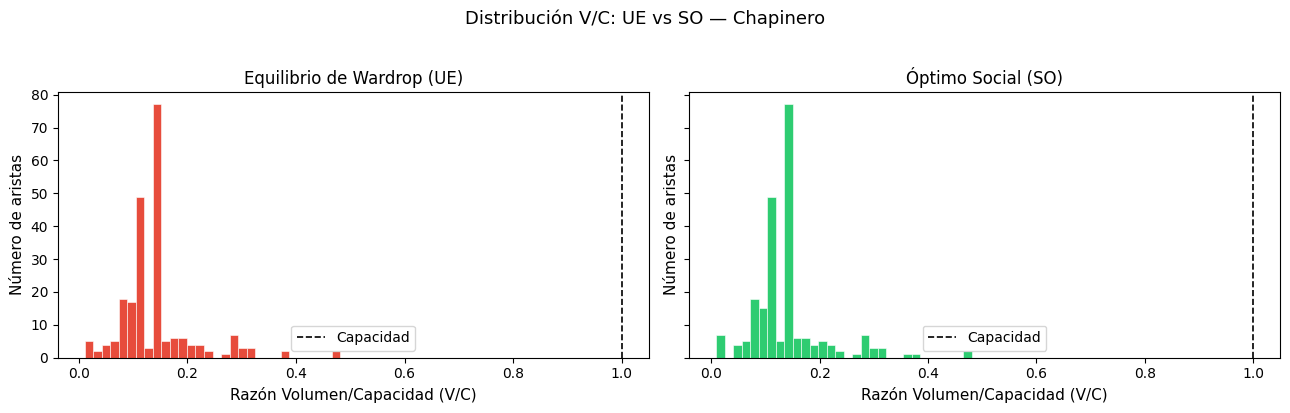

In [9]:
# Distribución de razón volumen/capacidad
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, vcr, label, color in [
    (axes[0], df_edges['vcr_ue'], 'Equilibrio de Wardrop (UE)', '#e74c3c'),
    (axes[1], df_edges['vcr_so'], 'Óptimo Social (SO)',          '#2ecc71'),
]:
    active = vcr[vcr > 0.001]
    ax.hist(active, bins=30, color=color, edgecolor='white', linewidth=0.4)
    ax.axvline(1.0, color='black', linestyle='--', linewidth=1.2, label='Capacidad')
    ax.set_xlabel('Razón Volumen/Capacidad (V/C)', fontsize=11)
    ax.set_ylabel('Número de aristas', fontsize=11)
    ax.set_title(label)
    ax.legend()

plt.suptitle('Distribución V/C: UE vs SO — Chapinero', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'so_vc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Visualización espacial: diferencia de flujos SO − UE

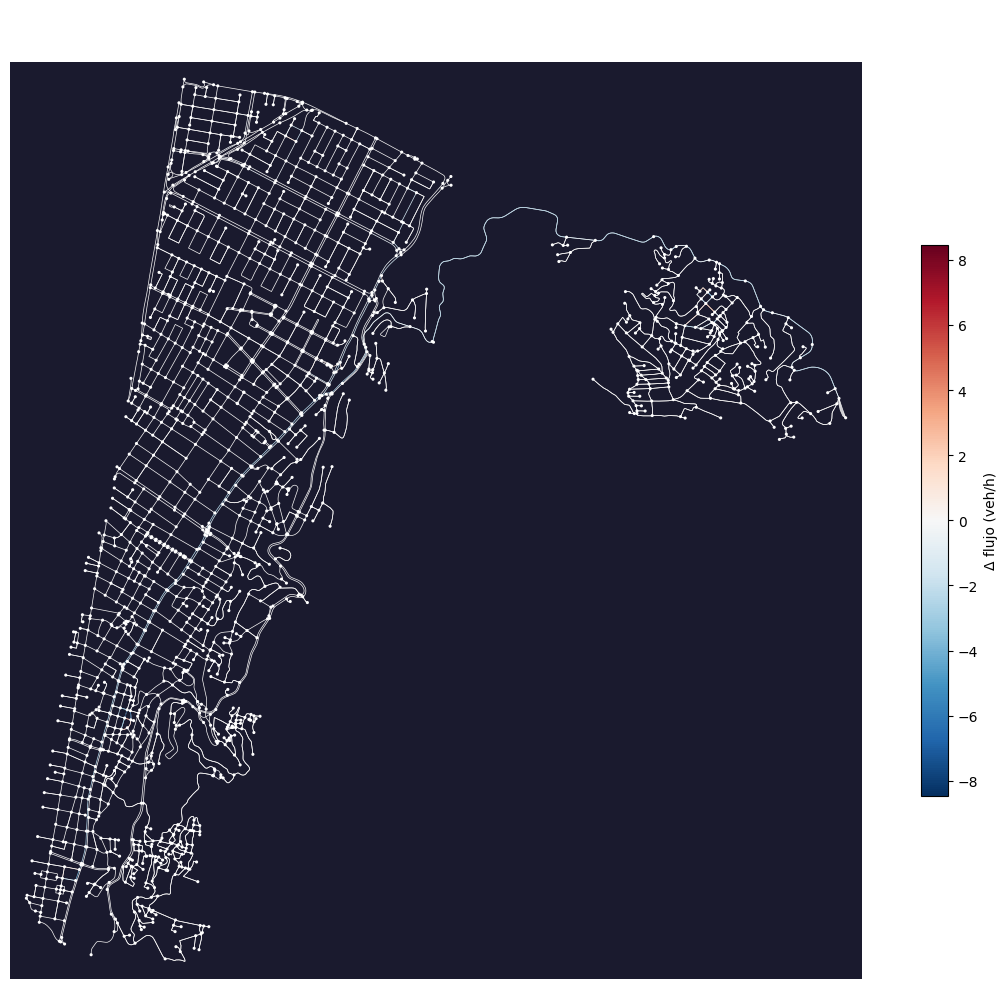

In [10]:
# Asignar diferencia al grafo
for i, (u, v, k) in enumerate(edges_list):
    G[u][v][k]['flow_so']   = float(x_so[i])
    G[u][v][k]['flow_diff'] = float(diff_flow[i])

# Colormap divergente: rojo = SO más cargado, azul = SO libera
max_diff = np.abs(diff_flow).max()
norm = mcolors.TwoSlopeNorm(vmin=-max_diff, vcenter=0, vmax=max_diff)
cmap = plt.get_cmap('RdBu_r')

edge_colors = [cmap(norm(diff_flow[i])) for i in range(E)]
edge_widths = [0.5 + abs(diff_flow[i]) / 150 for i in range(E)]

fig, ax = ox.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    node_size=5,
    node_color='white',
    bgcolor='#1a1a2e',
    figsize=(12, 10),
    show=False,
    close=False,
)
ax.set_title('Diferencia de flujos SO − UE (rojo: SO carga más, azul: SO libera)\nChapinero, Bogotá',
             color='white', fontsize=13, pad=12)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, orientation='vertical', shrink=0.6, label='Δ flujo (veh/h)')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'so_flow_diff.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Costo marginal social vs costo percibido

En el SO, el costo **marginal social** de añadir un vehículo en la arista $a$ es:

$$MC_a = t_a(x_a) + x_a \cdot t_a'(x_a) = t_a^0 \left(1 + 0.15 \cdot 5 \cdot \left(\frac{x_a}{c_a}\right)^4\right)$$

El conductor percibe solo $t_a(x_a)$. La diferencia es la **externalidad de congestión**,
que un peaje de Pigou podría internalizar.

Externalidad de congestión en aristas activas (peaje de Pigou, segundos):
  Media   : 0.0 s
  Máxima  : 0.3 s
  Mediana : 0.0 s


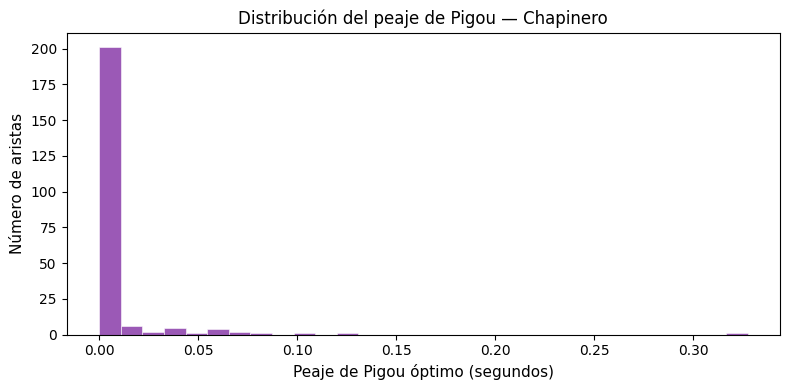

In [11]:
def marginal_cost_bpr(t0, x, cap, alpha=0.15, beta=4):
    """Costo marginal social: t(x) + x*t'(x)"""
    t_x   = t0 * (1 + alpha * (x / cap) ** beta)
    dt_dx = t0 * alpha * beta * (x ** (beta - 1)) / (cap ** beta)
    return t_x + x * dt_dx

mc_so = marginal_cost_bpr(t0, x_so, cap)
pigou_toll = mc_so - t_so   # externalidad = peaje de Pigou óptimo (segundos)

active = x_so > 1
print('Externalidad de congestión en aristas activas (peaje de Pigou, segundos):')
print(f'  Media   : {pigou_toll[active].mean():.1f} s')
print(f'  Máxima  : {pigou_toll[active].max():.1f} s')
print(f'  Mediana : {np.median(pigou_toll[active]):.1f} s')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pigou_toll[active], bins=30, color='#9b59b6', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Peaje de Pigou óptimo (segundos)', fontsize=11)
ax.set_ylabel('Número de aristas', fontsize=11)
ax.set_title('Distribución del peaje de Pigou — Chapinero')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'pigou_toll.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Guardar resultados

In [12]:
results_so = {
    **ue,                         # hereda todo lo de UE
    'x_so':       x_so,
    't_so':       t_so,
    'cost_so':    cost_so,
    'poa':        poa,
    'pigou_toll': pigou_toll,
    'diff_flow':  diff_flow,
}

out_path = PROCESSED_DIR / 'results_so.pkl'
with open(out_path, 'wb') as fh:
    pickle.dump(results_so, fh)

print(f'Resultados SO guardados en: {out_path}')
print(f'\nResumen final:')
print(f'  Costo UE        : {cost_ue:,.0f} veh·s')
print(f'  Costo SO        : {cost_so:,.0f} veh·s')
print(f'  Ahorro SO vs UE : {cost_ue - cost_so:,.0f} veh·s ({ineficiencia:.2f}%)')
print(f'  Price of Anarchy: {poa:.4f}')
print(f'\n→ Listo para Notebook 04 — Price of Anarchy')

Resultados SO guardados en: ../data/processed/results_so.pkl

Resumen final:
  Costo UE        : 424,939 veh·s
  Costo SO        : 420,942 veh·s
  Ahorro SO vs UE : 3,997 veh·s (0.95%)
  Price of Anarchy: 1.0095

→ Listo para Notebook 04 — Price of Anarchy
